<a href="https://colab.research.google.com/github/aronnaiqbal/220153_Logistic/blob/main/220153_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [10]:
df = pd.read_csv("/content/drive/MyDrive/ML_dataset/heart.csv")

In [11]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [13]:
df = df.dropna()

In [14]:
X = df.drop("target", axis=1)
y = df["target"]

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [18]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [19]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [20]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC Score:", auc)

Accuracy : 0.7922077922077922
Precision: 0.7956989247311828
Recall   : 0.8505747126436781
F1 Score : 0.8222222222222222
AUC Score: 0.9023846285812318


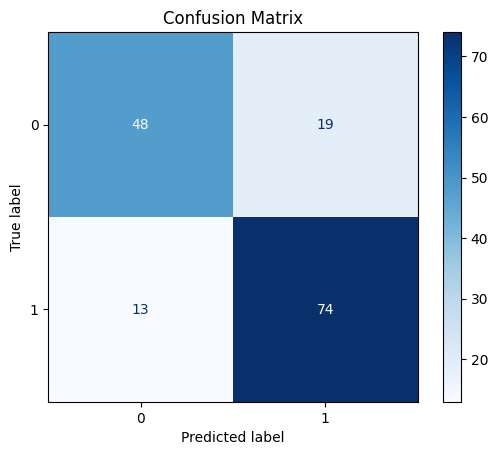

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

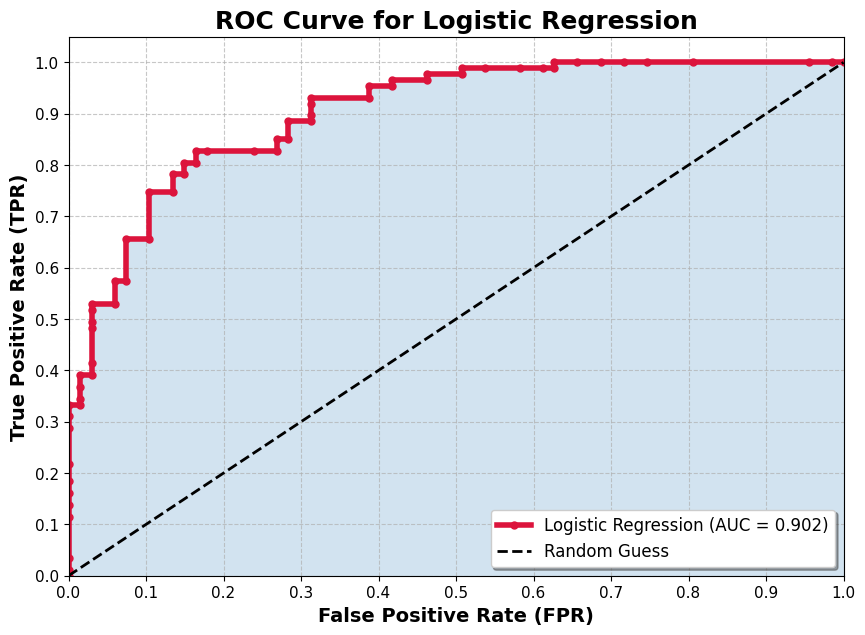

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(10,7))

plt.plot(
    fpr,
    tpr,
    color='crimson',
    linewidth=4,
    marker='o',
    markersize=5,
    label=f'Logistic Regression (AUC = {auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    color='black',
    linestyle='--',
    linewidth=2,
    label='Random Guess'
)

plt.fill_between(fpr, tpr, alpha=0.2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xticks(np.arange(0, 1.1, 0.1), fontsize=11)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=11)

plt.xlabel("False Positive Rate (FPR)", fontsize=14, fontweight='bold')
plt.ylabel("True Positive Rate (TPR)", fontsize=14, fontweight='bold')

plt.title(
    "ROC Curve for Logistic Regression",
    fontsize=18,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    shadow=True
)

plt.show()

In [24]:
results = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Probability": y_prob[:10]
})

print(results)

   Actual  Predicted  Probability
0       0          0     0.110617
1       0          0     0.021045
2       0          0     0.008259
3       1          1     0.514103
4       1          1     0.730665
5       1          0     0.439487
6       1          1     0.873190
7       1          1     0.834520
8       0          0     0.005216
9       0          0     0.120548
